In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: For pretty scientific plots
try:
    import scienceplots
    plt.style.use(["science", "grid", "high-vis", "no-latex"])
except ImportError:
    plt.style.use("default")

In [ ]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"] = "1"

In [ ]:
%env CUDA_LAUNCH_BLOCKING=1

env: CUDA_LAUNCH_BLOCKING=1


Imports and Setup

In [ ]:
import os
print(os.listdir('/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet/datasets/'))

['__pycache__', 'base_dataset.py', 'readme.txt', 'loveda.py', '__init__.py']


# RUN

Install Dependencies

In [2]:
!pip install tensorboardX thop albumentations tqdm pyyaml yacs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 4.3 MB/s eta 0:00:00


Generate dataset list files

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet

!python -m datasets.loveda

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
<frozen runpy>:128: RuntimeWarning: 'datasets.loveda' found in sys.modules after import of package 'datasets', but prior to execution of 'datasets.loveda'; this may result in unpredictable behaviour


In [ ]:
import sys

sys.path.append('/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet/')

sys.path.append('/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet/datasets/')

sys.path.append('/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet/tools/')

In [2]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python tools/train_dacs.py --cfg configs/loveda/pidnet_loveda_4b.yaml

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
Seeding with 304
=> creating output/loveda/pidnet_loveda_4b
=> creating log/loveda/pidnet_small/pidnet_loveda_4b_2025-08-26-18-33
Namespace(cfg='configs/loveda/pidnet_loveda_4b.yaml', seed=304, dacs_classmix_frac=0.5, dacs_loss_weight=0.1, dacs_pseudo_thr=0.968, opts=[])
AUTO_RESUME: False
CUDNN:
  BENCHMARK: True
  DETERMINISTIC: False
  ENABLED: True
DATASET:
  DATASET: loveda
  EXTRA_TRAIN_SET: 
  NUM_CLASSES: 7
  ROOT: data/
  TEST_SET: list/loveda/val_rural.lst
  TRAIN_SET: list/loveda/train_urban.lst
  TRAIN_SET_TARGET: list/loveda/train_rural.lst
GPUS: (0,)
LOG_DIR: log
LOSS:
  BALANCE_WEIGHTS: [0.4, 1.0]
  CLASS_BALANCE: False
  LAMBDA_ADV: 0.002
  OHEMKEEP: 131072
  OHEMTHRES: 0.9
  SB_WEIGHTS: 1.0
  USE_OHEM: True
MODEL:
  ALIGN_CORNERS: True
  NAME: pidnet_small
  NUM_OUTPUTS: 2
  PRETRAINED: ./pretrained_models/imagenet/PIDNet_S_ImageNet.pth.tar
OUTPUT_DIR: output
PIN_MEMORY: True
PRINT_FREQ: 10
TEST:
  BASE_SIZE: 1024

In [ ]:
%cd /content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet
!python tools/visualization.py --config configs/loveda/pidnet_loveda_3a.yaml --checkpoint output/loveda/pidnet_loveda_3a/best.pt --split val --output_dir visualizations --num_samples 10

/content/drive/MyDrive/AML_Semantic_Segmentation/PIDNet


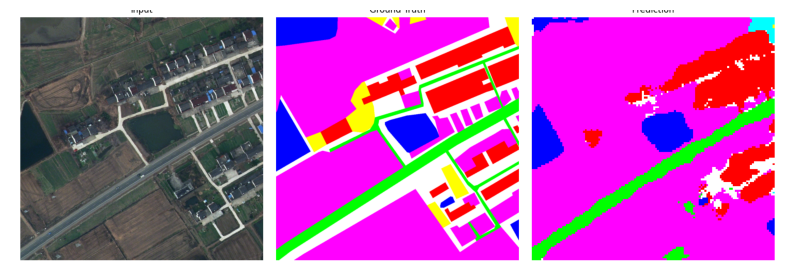

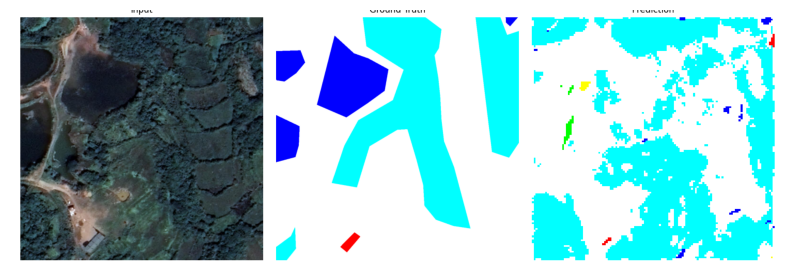

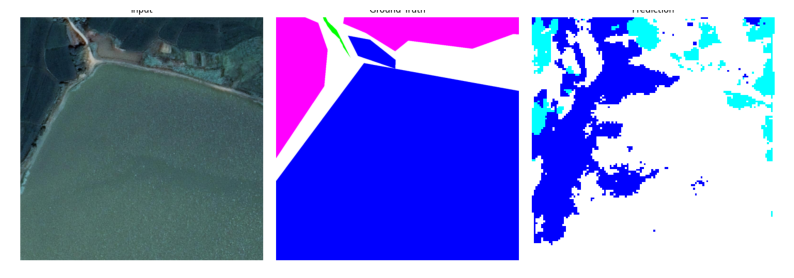

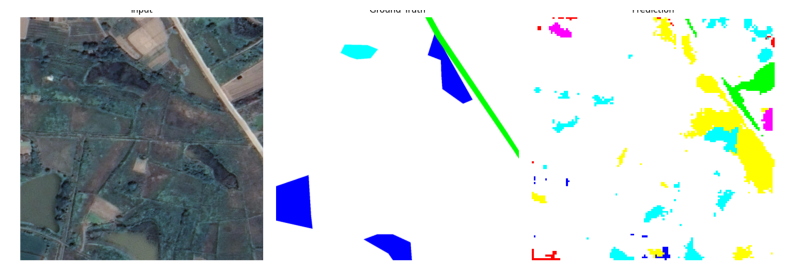

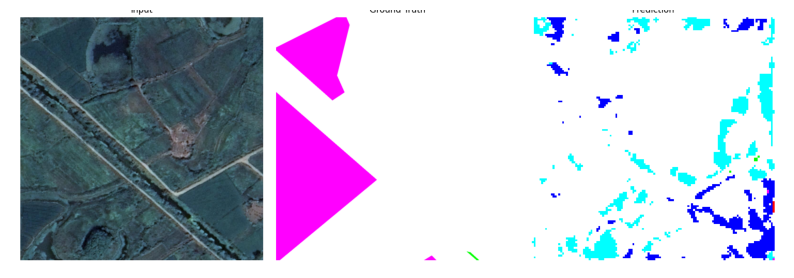

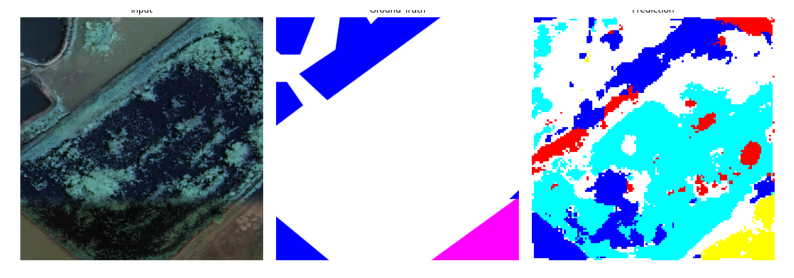

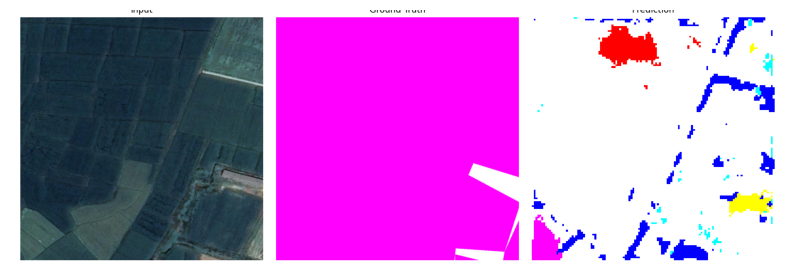

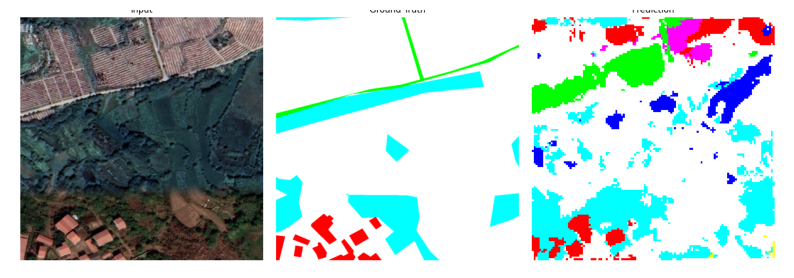

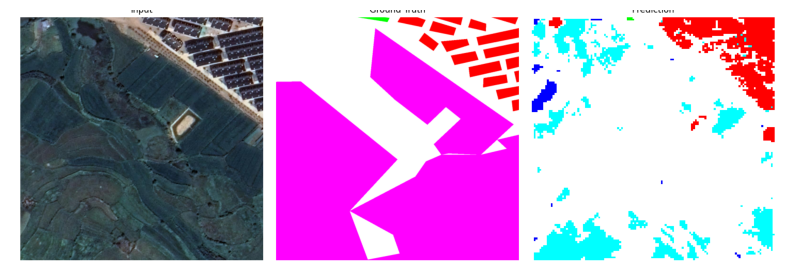

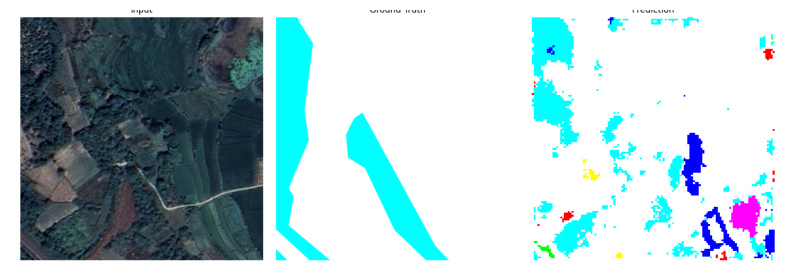

In [ ]:
import matplotlib.pyplot as plt
import glob
from PIL import Image

vis_dir = 'visualizations'
imgs = sorted(glob.glob(f"{vis_dir}/*.png"))
for img_path in imgs[:10]:
    img = Image.open(img_path)
    plt.figure(figsize=(10,5))
    plt.imshow(img)
    plt.axis('off')
    plt.show()